In [1]:
import numpy as np # Linear Algebra
import matplotlib.pyplot as plt # Plotting

In [2]:
# Simplest possible system
static = True
limits = False

Kp = 2.
Ki = 0.1

qd = 5.
def desired(t):
    if static:
        return qd # static
    return qd * np.cos(t)

def desired_v(t):
    if static:
        return 0. # static
    return -qd * np.sin(t)

q0 = -5.
max_v = 5.

def step(q, v, dt = 0.01):
    return q + v * dt

In [3]:
dt = 0.1
tf = 100.
K = int(tf / dt) + 1

noise_range = 0.
unmodeled_offset = 0.

In [5]:
def do_sim():
    all_qs = []
    all_es = []
    
    q = q0
    integral = 0.
    for k in range(K):
        qn = q + np.random.rand() * noise_range - noise_range / 2.
        e = (desired(k * dt) - qn)
        all_qs.append(qn)
        all_es.append(e)
        integral += e * dt
        v = desired_v(k * dt) + Kp * e + Ki * integral + unmodeled_offset
        if limits:
            v = min(max(v, -max_v), max_v) # control limits
        q = step(q, v, dt)
    return all_qs, all_es

In [6]:
def plot(all_qs, all_es):
    fig = plt.figure()  # no frame
    ax = fig.add_subplot(1, 1, 1)
    
    ax.plot([k * dt for k in range(K)], all_es, label="error")
    if not static:
        ax.plot([k * dt for k in range(K)], all_qs, label="actual")
        ax.plot([k * dt for k in range(K)], [desired(k * dt) for k in range(K)], label="desired")
    
    ax.legend()
    
    plt.show()

In [7]:
all_qs, all_es = do_sim()

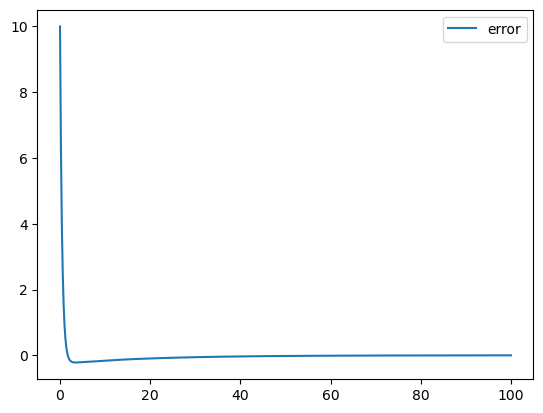

In [8]:
plot(all_qs, all_es)

In [9]:
Kp = 2.
Ki = 0.1

static = True
limits = False

noise_range = 0. # 1.
unmodeled_offset = 0. # 10.

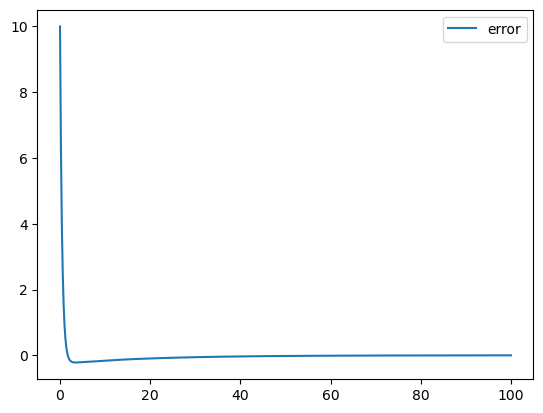

In [10]:
all_qs, all_es = do_sim()
plot(all_qs, all_es)